# Wednesday, April 29th, 2026

On Monday, we looked at simulating Conway's Game of Life in Python.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Recap:

We defined the `get_padded_cells` function (which was based on the analagous function from our Image Denoising project), which placed rows of non-living cells above and below and columns of non-living cells to the left and right of our `cells` array. This function returns this new `padded_cells` array.

In [2]:
def get_padded_cells(cells):
    nrows, ncols = cells.shape
    padded_cells = np.zeros((nrows+2, ncols+2), dtype=int)
    padded_cells[1:-1, 1:-1] = cells
    return padded_cells

Next, we wrote a function `get_live_neighbors_count` that takes in the `padded_cells` array along with row/column indices `i`/`j`, and counts the number of live neighbors that the `[i,j]`th cell has.

In [3]:
def get_live_neighbors_count(padded_cells, i, j):
    grid = padded_cells[i:i+3, j:j+3]      # The 3x3 grid centered on
                                           # cells [i,j] of the cells array
    live_neighbors_count = np.sum(grid) - grid[1,1]
    return live_neighbors_count

We also defined a function `update_cells` that takes in an array, `cells`, which stores a configuration of live/dead cells, and returns the next configuration after applying the rules of the Game of Life.

In [4]:
def update_cells(cells):
    nrows, ncols = cells.shape
    padded_cells = get_padded_cells(cells)

    updated_cells = cells.copy()
    for i in range(nrows):
        for j in range(ncols):
            live_neighbors_count = get_live_neighbors_count(padded_cells, i, j)
            if cells[i,j] == 1:     # If the cell is alive
                if live_neighbors_count in [2,3]: # And if it has two or three live neighbors
                    updated_cells[i,j] = 1       # then it stays alive
                else:                            # Otherwise,
                    updated_cells[i,j] = 0       # it dies
            elif cells[i,j] == 0:   # If the cell is dead
                if live_neighbors_count == 3:     # And if it has exactly three live neighbors
                    updated_cells[i,j] = 1       # then it becomes alive
                else:
                    updated_cells[i,j] = 0
    return updated_cells

To experiment, we defined a function `random_starting_state` that generates a random initial configuration of live/dead cells.

In [5]:
def random_starting_state(n, percent_live_cells):
    cells = np.zeros((n,n), dtype=int)
    random_array = np.random.random((n,n))
    live_mask = random_array < percent_live_cells
    cells[live_mask] = 1
    return cells

We also defined a function `simulate_game_of_life` to run the simulation with a given initial configuration, `cells`, for a given number of time steps `T`. This function returns a 3D array storing the entire history of the simulation.

In [6]:
def simulate_game_of_life(cells, T):
    cells_history = np.zeros((n,n,T), dtype=int)        # 3D array to store all configurations of cells
    cells_history[:,:,0] = cells     # Store the initial configuration
    
    for t in range(1,T):
        cells = update_cells(cells)
        cells_history[:,:,t] = cells
    return cells_history

Finally, we started discussing ideas on how to quantitatively explore and visualize this data.

In [8]:
T = 100 # Number of steps to simulate
n = 200  # Grid
percent_live_cells = .1

cells = random_starting_state(n, percent_live_cells)  # Initial configuration
cells_history = simulate_game_of_life(cells, T)

We looked at two ideas for reducing the dimensionality of the problem.
First, we produced a heatmap that collapsed the time dimension by adding up all of the time steps for which a cell was alive (separately for each cell).

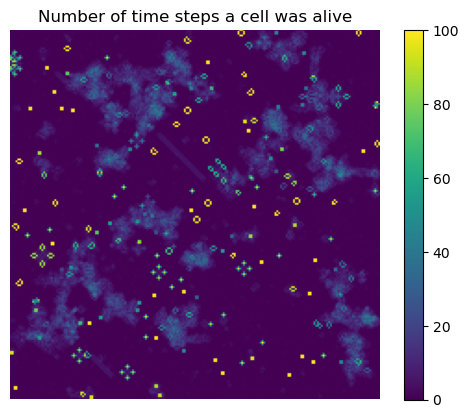

In [10]:
num_time_steps_alive = cells_history.sum(axis=2)

plt.imshow(num_time_steps_alive)
plt.axis('off')
plt.title('Number of time steps a cell was alive')

plt.colorbar()
plt.show()

We also collapsed the two spatial dimensions (rows/columns) by adding up the number of live cells separately for each time step.

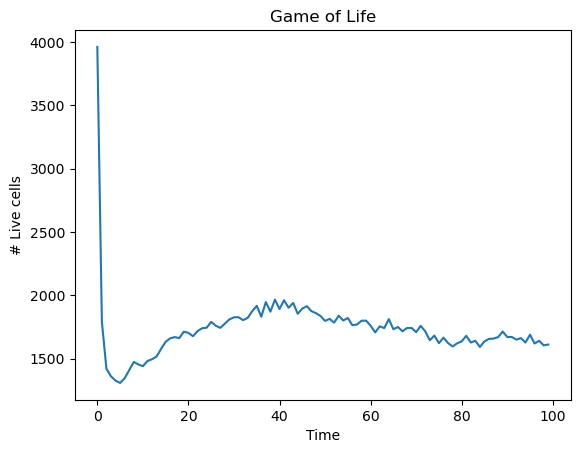

In [11]:
num_live_cells = cells_history.sum(axis=(0,1))

t = np.arange(T)
plt.plot(t, num_live_cells)

plt.xlabel('Time')
plt.ylabel('# Live cells')
plt.title('Game of Life')

plt.show()

## Further analysis of the number of live cells

There are many things we can do to continue studying the dynamics of the Game of Life by looking at how the number of live cells changes over time. Here are just a few ideas.

**Exercise:** For a given choice of parameters `n` (the square grid size), `percent_live_cells` (the portion of randomly selected cells that will be initially set to living), and `T` (number of time steps to simulate), simulate the Game of Life many times. For each of these simulations, plot the number of live cells as a function of time in a single plot. Also include the average (across the numerous simulations) number of live cells per time step.

**Exercise:** For a given choice of parameters `n` and `T`, simulate the Game of Life with several different choices of `percent_live_cells` used to generate the random initial configuration. Plot the number of live cells as a function of time for these numerous simulations in a single plot.

**Exercise:** For a given choice of parameters `percent_live_cells` and `T`, simulate the Game of Life with several different choices of square grid size `n`. Instead of plotting the number of live cells as a function of time, normalize this count by the size of the grid (e.g. by dividing by `n**2`). Plot this normalized count for each of the simulations in a single plot.

**Exercise:** For a given choice of parameter `T`, simulate the Game of Life with several combinations of choices for `n` and `percent_live_cells`. For each simulation, calculate the average number of live cells from the last `10` times steps (choose `T > 10` at least). Create an array to store this data and use `plt.imshow` to visualize this array.

## [Project 6: Epidemic](https://jllottes.github.io/Projects/epidemic/epidemic.html)

For the last project, we will be simulating the spread of an epidemic. Like the Game of Life, we will model this as a grid of cells, where the configuration at each step determines the configuration for the next step. Unlike the Game of Life, our epidemic model includes some amount of randomness in the "rules" (see the project page for these rules).

**Exercise:** Create a function `get_sick_neighbors_count` (analogous to the `get_live_neighbors_count` from the Game of Life) to count the number of sick neighbors a given cell has. 

*Note: Unlike the Game of Life (which only has two states, `0` (dead) and `1` (alive)), with the epidemic model we have several states. You will need to account for this when counting the number of sick neighbors.*

**Exercise:** Create a function `update_spread` (analogous to `update_cells` from the Game of Life) that takes in a configuration of `cells` and applies the rules of the epidemic model to return the next configuration.

**Exercise:** Create a function `simulate_epidemic` that takes in an initial configuration of cells along with parameters `p_I` and `p_R` that control the probability of infection and the probability of recovery, and returns 3D array storing the entire history of cell configurations.

Once we have these functions, we can start exploring the dynamics of the epidemic model in a similar fashion to our discussion of the Game of Life.